In [1]:
from pathlib import Path
from tqdm import tqdm
import json
tqdm.pandas()
#
import biotite.sequence as seq
import biotite.sequence.io.fasta as fasta
from biotite.sequence.align import Alignment
import biotite.sequence.graphics as graphics
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

#### Sequence filtering

##### Plot

In [6]:
# visualize sequences designed
def plot_seqs(df, structure_name, start=0, show_seqs=5, scheme='zappo'):
    # read df of sequences (not incl input)
    df = df[df['id'].str.contains(structure_name)]

    # "align" (stack) sequences
    alignment = Alignment(
        [
            seq.ProteinSequence(s)
            for s in df['sequence']
        ],
        Alignment.trace_from_strings(list(df['sequence']))
    )

    # plot sequence logo
    profile = seq.SequenceProfile.from_alignment(alignment)
    fig, ax = plt.subplots(figsize=(18, 3))
    graphics.plot_sequence_logo(
        ax,
        profile,
        scheme=scheme
    )
    ax.set_xlabel('residue', fontsize=20, fontweight='bold')
    ax.set_ylabel('bits', fontsize=20, fontweight='bold')
    ax.set_xlim(start, ax.get_xlim()[1])
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    fig.tight_layout()
    plt.show()

    # plot first few sequences
    fig, ax = plt.subplots(figsize=(18, 6))
    graphics.plot_alignment_type_based(
        ax,
        alignment[:, :show_seqs],
        labels=list(df.index[:show_seqs]),
        show_numbers=True,
        color_scheme=scheme,
        color_symbols=True,
        symbols_per_line=int(len(df.iloc[0, 1]) / 2), #type: ignore
        symbol_size = 24,
        spacing = 1
    )
    fig.tight_layout()
    plt.show()

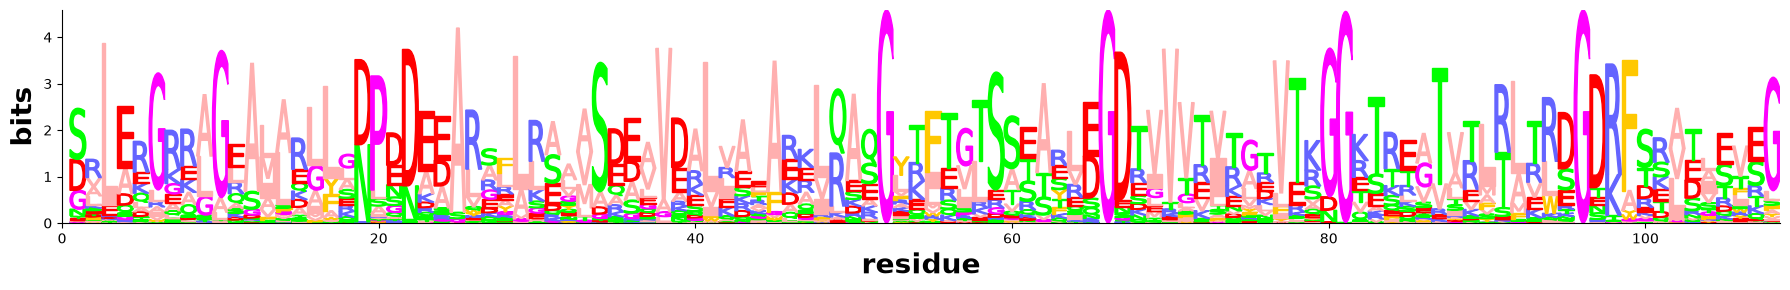

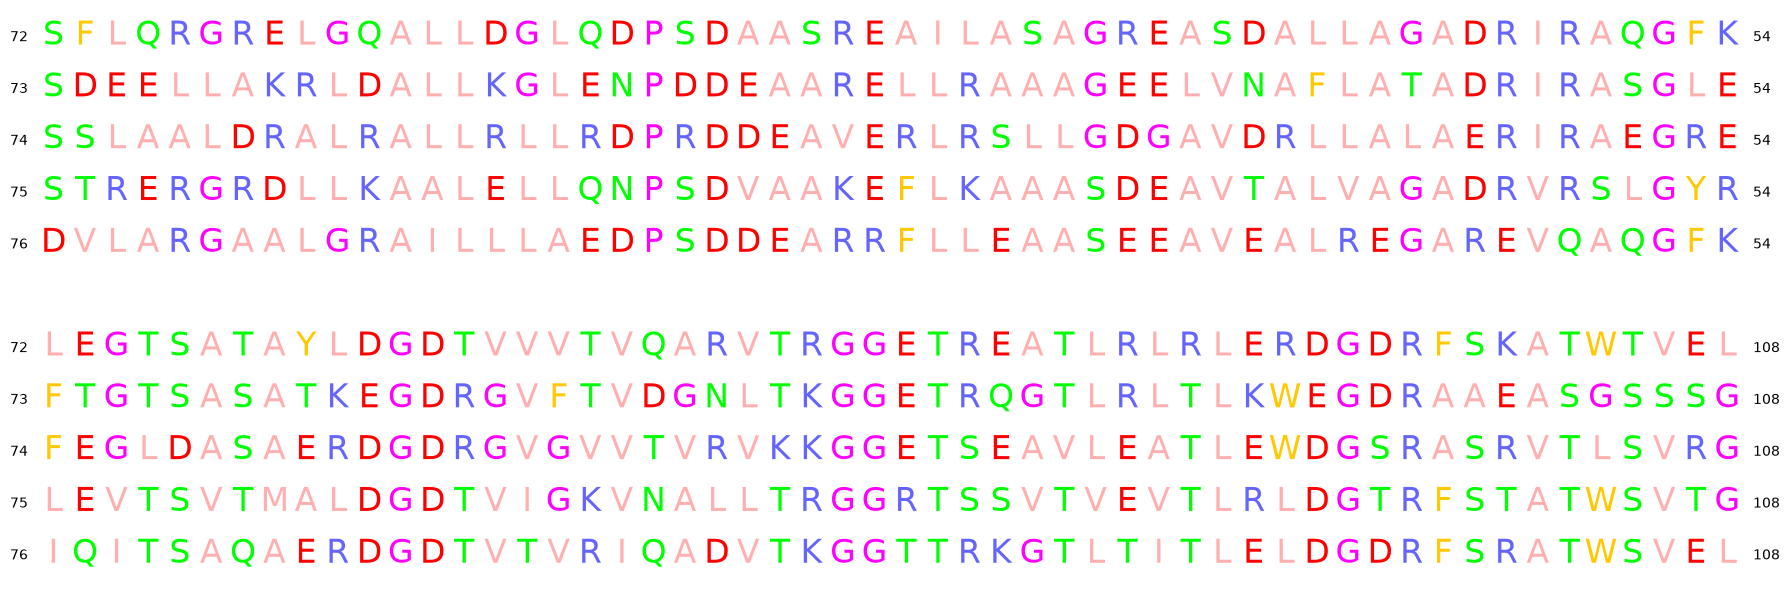

In [35]:
plot_seqs(dfs['0.3'], '5KPE')

##### Filter

In [31]:
# read in sequences
dfs = {
    '0.1': pd.read_csv(f'/wynton/home/rotation/geanhu/multi-state/data/mpnn-output/5KPE-5KPH_multi-state/temp1/seqs/seqs.csv'),
    '0.2': pd.read_csv(f'/wynton/home/rotation/geanhu/multi-state/data/mpnn-output/5KPE-5KPH_multi-state/temp2/seqs/seqs.csv'),
    '0.3': pd.read_csv(f'/wynton/home/rotation/geanhu/multi-state/data/mpnn-output/5KPE-5KPH_multi-state/temp3/seqs/seqs.csv')
}

In [24]:
# re-organize Caliby outputs dfs
for temp in dfs:
    df = dfs[temp].copy()
    df['id'] = df.apply(
        lambda row: f'{row['example_id'][:-2]}_id{row['out_pdb'].split('_sample')[1].split('.')[0]}',
        axis=1
    ) #type: ignore
    df['sequence'] = df['seq']
    df = df[['id', 'sequence']]
    dfs[temp] = df.copy()

In [32]:
# filter out runs
def longest_run(input):
    prev_char = None
    longest_run = 0
    current_run = 0

    for character in input:
        if character == prev_char:
            current_run += 1
        else:
            current_run = 0
            prev_char = character
        #
        if current_run > longest_run:
            longest_run = current_run
    #
    return longest_run

max_run = 4
def filter_runs(sequence):
    return longest_run(sequence) < max_run

for temp in dfs:
    # filter out sequences
    mask = dfs[temp]['sequence'].apply(filter_runs)
    filtered_df = dfs[temp][mask]

    # report stats
    print(f'For temp {temp}, {len(filtered_df)} of {len(dfs[temp])} remain')

    # keep filtered
    dfs[temp] = filtered_df.copy()

For temp 0.1, 3907 of 4128 remain
For temp 0.2, 3935 of 4128 remain
For temp 0.3, 3974 of 4128 remain


In [36]:
max_comp = 0.25
enriched_aas = []
def filter_lcp(sequence):
    sequence_array = np.array(list(sequence))
    aas, counts = np.unique(sequence_array, return_counts=True)
    comp = np.max(counts) / len(sequence)
    if comp < max_comp:
        return True
    else:
        enriched_aas.append(aas[np.argmax(counts)])
        return False

for temp in dfs:
    # filter out sequences
    mask = dfs[temp]['sequence'].apply(filter_lcp) #type:ignore
    filtered_df = dfs[temp][mask]

    # report stats
    print(f'For temp {temp}, {len(filtered_df)} of {len(dfs[temp])} remain')

    # keep filtered
    dfs[temp] = filtered_df.copy()

# print which AAs enriched > threshold
enriched_aa, enriched_count = np.unique(enriched_aas, return_counts=True)
for (aa, count) in zip(enriched_aa, enriched_count):
    print(f'{aa}: {count}')

For temp 0.1, 3855 of 3907 remain
For temp 0.2, 3910 of 3935 remain
For temp 0.3, 3966 of 3974 remain
A: 53
E: 11
K: 1
Q: 3
R: 8
S: 6
T: 3


In [37]:
# check # of unique backbones remaining
def backbone(name):
    return '_'.join(name.split('_')[:4]) #5

backbones_original = []
for temp in dfs:
    backbones = dfs[temp]['id'].apply(backbone)
    backbones_original.append(np.unique(backbones))

for backbones in backbones_original:
    print(len(backbones))

172
172
172


In [38]:
# duplicate sequences
for temp in dfs:
    pre_count = len(dfs[temp])
    dfs[temp] = dfs[temp].sort_values(by='id')
    dfs[temp] = dfs[temp].drop_duplicates(
        subset=['sequence'],
        keep = 'last'
    )
    post_count = len(dfs[temp])
    print(f'Dropped {post_count - pre_count} duplicate sequences')

Dropped 0 duplicate sequences
Dropped 0 duplicate sequences
Dropped 0 duplicate sequences


In [39]:
# save filtered dfs
for temp in dfs:
    save_path = f'/wynton/home/rotation/geanhu/multi-state/data/mpnn-output/5KPE-5KPH_multi-state/temp{temp[-1]}/filtered_seqs.csv'
    dfs[temp].to_csv(save_path, index=False)

print(dfs[temp].loc[0, 'sequence'])

SEEEEKEQAAKLALAGLQKQFPDATATLLSLEVDGDMVTITVELKQDGKTGKFKLTLTREGDNVRILSMEKV


#### Assessing designs

In [20]:
# read in both RMSDs
def json_to_df(jsonpath, name):
    with open(jsonpath, 'r') as file:
        data = json.load(file)
    
    return pd.DataFrame({
        'path': [key for key in data],
        f'rmsd_{name}': [data[key] for key in data]
    })

start_rmsd = json_to_df('/wynton/home/rotation/geanhu/multi-state/data/colabfold-output/5KPE-5KPH_multi-state/temp1/rmsd_CA_rmsd_paths_start.json', 'start')
end_rmsd = json_to_df('/wynton/home/rotation/geanhu/multi-state/data/colabfold-output/5KPE-5KPH_multi-state/temp1/rmsd_CA_rmsd_paths_end.json', 'end')
rmsd_df = start_rmsd.join(end_rmsd.set_index("path"), on="path")
rmsd_df['rmsd_constraint'] = rmsd_df['path'].apply(
    lambda pathstring: int(pathstring.split('/')[-1][5])
)

210


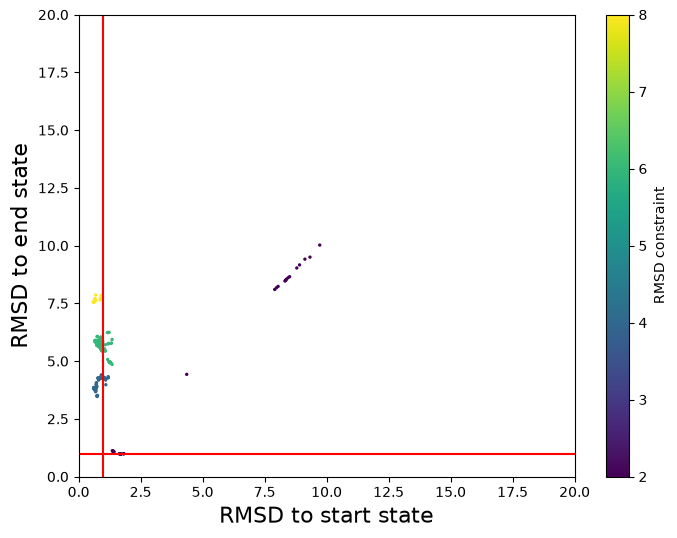

In [35]:
structure = '5KPH'
df = rmsd_df[rmsd_df['path'].apply(
    lambda pathstring: structure in pathstring.split('/')[-1]
)]
print(len(df))
#
plt.figure(figsize=(8, 6))
plt.scatter(
    df['rmsd_start'],
    df['rmsd_end'],
    c = df['rmsd_constraint'],
    s = 2
)
plt.colorbar(label = 'RMSD constraint')
plt.xlabel('RMSD to start state', fontsize=16)
plt.ylabel('RMSD to end state', fontsize=16)
plt.xlim(0, 20)
plt.ylim(0, 20)
#
plt.axhline(
    y = 1,
    color = 'red'
)
plt.axvline(
    x = 1,
    color = 'red'
)
plt.show()